# Behavioral Control

In [ ]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size


dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice' : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)

## RP control

In [2]:
from beh_control import control_view # import the function

# define which setup from the control table you want to see
control_view(['ef-rp3', 'ef-rp18', 'ef-rp167', 'ef-rp160', 'ef-rp163', 'ef-rp165', 'ef-rp18', 'ef-rp19', 'ef-rp167'])

setup,status,animal_id,task_idx,session,trials,total_liquid,state,difficulty,start_time,stop_time,notes,last_ping
ef-rp160,ready,404,3,102,0,0,,1,12:00:00,14:00:00,,2026-05-28 23:16:57
ef-rp163,ready,299,592,576,0,0,,1,12:00:00,14:00:00,,2026-05-28 23:16:54
ef-rp165,ready,410,3,105,0,0,,1,09:00:00,11:00:00,,2026-05-28 23:16:53
ef-rp167,sleeping,288,625,585,475,1200,Offtime,1,12:00:00,14:20:00,,2026-05-28 23:16:55
ef-rp18,sleeping,402,589,127,503,900,PreTrial,1,12:00:00,12:50:00,,2026-05-28 12:49:57
ef-rp19,sleeping,328,592,376,1058,1182,Offtime,2,12:00:00,14:00:00,,2026-05-28 23:16:55
ef-rp3,ready,418,3,72,0,0,,1,12:00:00,14:00:00,,2026-05-28 23:16:53


In [8]:
# See the performance of each animal 
# complete the animal_id and session
key_rp160 = {"animal_id": 404, "session_ids": [102]}
# key_rp163 = {"animal_id": 299, "session_ids": []}
key_rp165 = {"animal_id": 410, "session_ids": [105]} 
key_rp167 = {"animal_id": 288, "session_ids": [585]}  # NeuroPixel rp
key_rp18 = {"animal_id": 402, "session_ids": [127]} 
key_rp19 = {"animal_id": 328, "session_ids": [376]} 
key_rp3 = {"animal_id": 418, "session_ids": []} 

In [9]:
from beh_control import (
trials_per_session, 
select_sess_dates, 
find_Stimuli_behavior_experiment, 
difficultyPlot,
perf_difficulty,
compute_perf
)

# --- Parameters ---
animals_to_run = [
    {"animal_id": key_rp19['animal_id'], "session_ids": key_rp19['session_ids']},
    {"animal_id": key_rp160['animal_id'], "session_ids": key_rp160['session_ids']}, 
    {"animal_id": key_rp18['animal_id'], "session_ids": key_rp18['session_ids']}, 
    {"animal_id": key_rp165['animal_id'], "session_ids": key_rp165['session_ids']}, 
    # {"animal_id": key_rp163['animal_id'], "session_ids": key_rp163['session_ids']},
    {"animal_id": key_rp3['animal_id'], "session_ids": key_rp3['session_ids']}, 
    {"animal_id": key_rp167['animal_id'], "session_ids": key_rp167['session_ids']} 
]

for entry in animals_to_run:
    animal_id = entry["animal_id"]
    session_ids = entry["session_ids"]

    print(f"\n================ Animal {animal_id} ================")

    # --- Define filtering ONCE per animal ---
    animal_sessions_tc = trials_per_session(animal_id, min_trials=2)
    animal_sessions_dt = select_sess_dates(
        animal_id,
        from_date="2025-03-26",
        to_date="2029-03-26"
    )

    selected_sessions = animal_sessions_tc * animal_sessions_dt
    valid_sessions = set(selected_sessions.fetch("session"))

    # --- Loop through sessions for this animal ---
    for session in session_ids:
        if session not in valid_sessions:
            print(f"Skipping session {session}: does not meet criteria.")
            continue

        key_animal_session = {
            "animal_id": animal_id,
            "session": session
        }

        # Session metadata
        session_classes = find_Stimuli_behavior_experiment(
            key_animal_session, exp
        )

        print(f"\n{key_animal_session}")
        print(
            "date:",
            (exp.Session & key_animal_session).fetch1("session_tmst")
        )

        for class_ in session_classes.columns:
            print(f"{class_}: {session_classes[class_].values[0]}")

        protocol = (
            exp.Session.Task & key_animal_session
        ).fetch1("task_name").split("/")[-1]
        print("protocol used:", protocol)

        # Performance analysis
        perf_difficulty(key_animal_session, compute_perf)
        print("---------------------------------------------------")


================ Animal 328 ================

{'animal_id': 328, 'session': 376}
date: 2026-05-28 12:04:32
stimulus_class: TonesPanda
behavior_class: MultiPort
experiment_class: MatchPort
protocol used: 2AFC_morphs_dif2_vol15_catch.py

difficulty: 2
performance: 0.56, Reward: 197, Punish:154, Abort: 706
---------------------------------------------------

================ Animal 404 ================

{'animal_id': 404, 'session': 102}
date: 2026-05-28 12:00:02
stimulus_class: TonesPanda
behavior_class: MultiPort
experiment_class: MatchPort
protocol used: 2AFC_morphs_dif1.py

difficulty: 1
performance: 0.58, Reward: 200, Punish:144, Abort: 172
---------------------------------------------------

================ Animal 402 ================

{'animal_id': 402, 'session': 127}
date: 2026-05-28 12:00:02
stimulus_class: TonesPanda
behavior_class: MultiPort
experiment_class: MatchPort
protocol used: 2AFC_morphs_dif1.py

difficulty: 1
performance: 0.57, Reward: 150, Punish:114, Abort: 238
--

## Mouse weight control

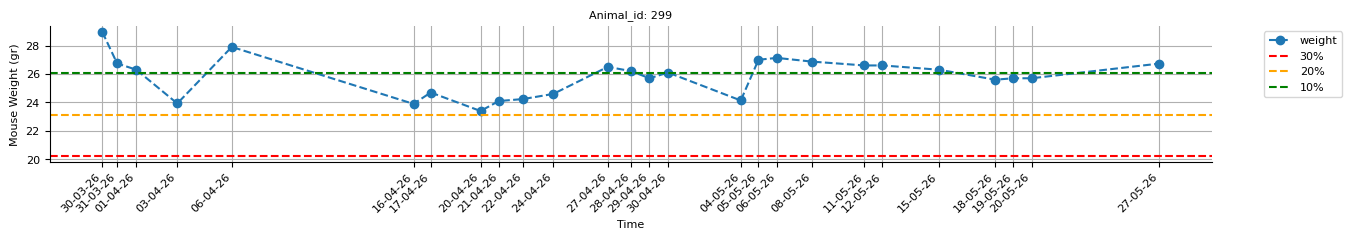

In [3]:
from beh_control import plot_weight

animal_id = 299

if animal_id == 299:
    from_date = "2026-03-30"
elif animal_id == 288:
    from_date = "2026-04-20"
elif animal_id == 418:
    from_date = "2026-05-20"
elif animal_id in (410,328):
    from_date = "2026-05-17"
elif animal_id in (402,404):
    from_date = "2026-04-22"
else:
    from_date = "2024-08-20"

plot_weight({"animal_id": animal_id}, from_date, figsize=(15,2))

## Exclude sessions

In [5]:
animal = 0
sessions_to_exclude = []  # list of sessions you want to exclude

for session in sessions_to_exclude:
    exp.Session.Excluded.insert1({
        'animal_id': animal, 
        'session': session, 
        'reason': 'abort'   # type the reason
    }, skip_duplicates=True)


In [6]:
#verify that you exlude the session
pd.set_option('display.max_colwidth', None)

data = pd.DataFrame(exp.Session.Excluded() & {'animal_id': animal})
data

,animal_id,session,reason,timestamp
0,0,2,aborted,2024-12-02 10:38:59
1,0,3,aborted,2024-12-02 10:41:22
2,0,7,aborted,2024-12-02 11:03:23
3,0,8,aborted,2024-12-02 11:12:22
4,0,311,aborted,2024-12-05 09:29:43
...,...,...,...,...
71,0,9633,aborted,2026-03-13 09:51:42
72,0,9783,aborted,2026-03-17 17:16:05
73,0,9850,aborted,2026-03-18 11:24:16
74,0,10655,aborted,2026-05-19 11:53:43
